# 05b · Prediction of NP1PAIN worsening — full 1,485-patient cohort

Notebook 05 on the matched 74-patient subset had AUC ≈ chance. This version trains on the **full PPMI cohort (n=1,485)** using baseline covariates PLUS **pre-anchor trajectory features** (pre mean, slope, last value, max, SD, count). Outcome = `worsened` (Δ ≥ 1 point from pre [−24,0] to post [+6,+18]).

Evaluation: 5-fold CV on the full cohort. Then calibrated performance on the DBS subset separately (as a subgroup).

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(purrr); library(forcats)
  library(glmnet); library(randomForest); library(xgboost); library(pROC)
})

rel <- load_full_ppmi_rel()
cat("Full rel rows:", nrow(rel), "  patients:", dplyr::n_distinct(rel$PATNO), "\n")

Full rel rows: 30428   patients: 1485 


In [2]:
feat <- build_per_patient_features(rel, var = "NP1PAIN",
                                   pre_win = c(-24, 0), post_win = c(6, 18))
cat("Patients with both pre and post windows:", nrow(feat), "\n")
print(dplyr::count(feat, worsened, name = "n"))

# Baseline covariates at/near anchor: earliest visit within [−24, 0] if any,
# else earliest available visit
base_vars <- c("age_at_visit","ageonset","duration_yrs","SEX","fampd","BMI",
               "LEDD","updrs3_score","NHY","NP1DPRS","NP1ANXS","gds","stai","scopa")
base_near <- rel %>% dplyr::filter(months >= -24, months <= 0) %>%
  dplyr::arrange(PATNO, dplyr::desc(months), INFODT_orig) %>%
  dplyr::group_by(PATNO) %>% dplyr::slice_head(n = 1) %>% dplyr::ungroup() %>%
  dplyr::select(PATNO, will_receive_dbs, dplyr::any_of(base_vars))

dat <- feat %>% dplyr::inner_join(base_near, by = "PATNO")
cat("Analytic n (feat ∩ baseline):", nrow(dat), "\n")
print(dplyr::count(dat, will_receive_dbs, worsened, name = "n"))
save_object(dat, "full_cohort_features")

Patients with both pre and post windows: 177 


# A tibble: 2 × 2
  worsened     n
     <int> <int>
1        0   146
2        1    31


Analytic n (feat ∩ baseline): 177 


# A tibble: 4 × 3
  will_receive_dbs worsened     n
  <lgl>               <int> <int>
1 FALSE                   0    90
2 FALSE                   1    20
3 TRUE                    0    56
4 TRUE                    1    11


In [3]:
# Design matrix + median imputation
median_impute <- function(x) { x[is.na(x)] <- stats::median(x, na.rm = TRUE); x }

feature_cols <- c(
  "dbs", "age_at_visit","ageonset","duration_yrs","SEX","BMI",
  "LEDD","updrs3_score","NHY","NP1DPRS","NP1ANXS","gds","stai","scopa",
  "pre_mean","pre_max","pre_sd","pre_last","pre_slope","pre_n"
)

X_df <- dat %>% dplyr::mutate(dbs = as.integer(will_receive_dbs)) %>%
  dplyr::select(dplyr::all_of(feature_cols)) %>%
  dplyr::mutate(dplyr::across(dplyr::everything(), median_impute))

X <- as.matrix(X_df)
y <- dat$worsened
cat("Design matrix:", nrow(X), "x", ncol(X), "  prevalence(worsened) =", round(mean(y), 3), "\n")

Design matrix: 177 x 20   prevalence(worsened) = 0.175 


In [4]:
# 5-fold CV
set.seed(42)
folds <- sample(rep(seq_len(5), length.out = nrow(X)))

cv_predict <- function(fit_fn) {
  preds <- numeric(nrow(X))
  for (k in seq_len(5)) {
    te <- which(folds == k); tr <- setdiff(seq_len(nrow(X)), te)
    preds[te] <- fit_fn(X[tr, , drop = FALSE], y[tr], X[te, , drop = FALSE])
  }
  preds
}

fit_enet <- function(Xtr, ytr, Xte) {
  cv <- glmnet::cv.glmnet(Xtr, ytr, family = "binomial", alpha = 0.5, nfolds = 5)
  as.numeric(predict(cv, newx = Xte, s = "lambda.min", type = "response"))
}
fit_rf <- function(Xtr, ytr, Xte) {
  m <- randomForest::randomForest(x = Xtr, y = factor(ytr, levels = c(0,1)),
                                  ntree = 500, nodesize = 5)
  as.numeric(predict(m, newdata = Xte, type = "prob")[, "1"])
}
fit_xgb <- function(Xtr, ytr, Xte) {
  dtr <- xgboost::xgb.DMatrix(Xtr, label = ytr)
  m <- xgboost::xgb.train(
    params = list(objective = "binary:logistic", eta = 0.05, max_depth = 4,
                  subsample = 0.8, colsample_bytree = 0.8, verbosity = 0),
    data = dtr, nrounds = 400, verbose = 0)
  as.numeric(predict(m, Xte))
}

set.seed(42); p_enet <- cv_predict(fit_enet)
set.seed(42); p_rf   <- cv_predict(fit_rf)
set.seed(42); p_xgb  <- cv_predict(fit_xgb)
cat("CV predictions computed.\n")

CV predictions computed.


In [5]:
metrics <- function(name, p, y) {
  auc <- suppressMessages(as.numeric(pROC::auc(pROC::roc(y, p, quiet = TRUE))))
  brier <- mean((p - y)^2)
  tibble::tibble(model = name, AUC = auc, Brier = brier)
}
res <- dplyr::bind_rows(
  metrics("Elastic Net",  p_enet, y),
  metrics("Random Forest", p_rf,   y),
  metrics("XGBoost",      p_xgb,  y),
  metrics("Naive (prevalence)", rep(mean(y), length(y)), y)
)
print(res)
save_table(res, "prediction_full_cohort_metrics")

# A tibble: 4 × 3
  model                AUC Brier
  <chr>              <dbl> <dbl>
1 Elastic Net        0.411 0.160
2 Random Forest      0.577 0.165
3 XGBoost            0.518 0.173
4 Naive (prevalence) 0.5   0.144


In [6]:
# Subgroup performance on DBS patients (as a held-out subgroup but CV-ed over all)
dbs_idx <- dat$will_receive_dbs
sub_res <- dplyr::bind_rows(
  metrics("Elastic Net · DBS",  p_enet[dbs_idx], y[dbs_idx]),
  metrics("Random Forest · DBS", p_rf[dbs_idx],   y[dbs_idx]),
  metrics("XGBoost · DBS",      p_xgb[dbs_idx],  y[dbs_idx]),
  metrics("Elastic Net · Never-DBS",  p_enet[!dbs_idx], y[!dbs_idx]),
  metrics("Random Forest · Never-DBS", p_rf[!dbs_idx],   y[!dbs_idx]),
  metrics("XGBoost · Never-DBS",      p_xgb[!dbs_idx],  y[!dbs_idx])
)
print(sub_res)
save_table(sub_res, "prediction_full_cohort_subgroup")

# A tibble: 6 × 3
  model                       AUC Brier
  <chr>                     <dbl> <dbl>
1 Elastic Net · DBS         0.532 0.136
2 Random Forest · DBS       0.722 0.164
3 XGBoost · DBS             0.604 0.180
4 Elastic Net · Never-DBS   0.666 0.175
5 Random Forest · Never-DBS 0.507 0.166
6 XGBoost · Never-DBS       0.541 0.168


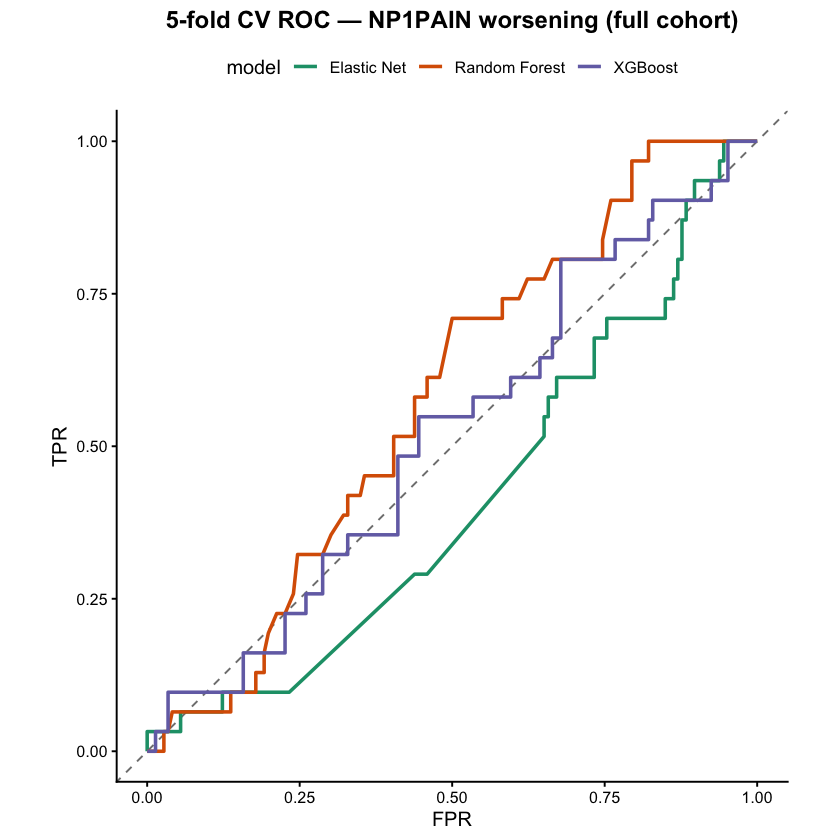

In [7]:
roc_df <- purrr::map_dfr(
  list(`Elastic Net` = p_enet, `Random Forest` = p_rf, XGBoost = p_xgb),
  function(p) {
    r <- pROC::roc(y, p, quiet = TRUE)
    tibble::tibble(fpr = 1 - r$specificities, tpr = r$sensitivities)
  }, .id = "model")
p_roc <- ggplot(roc_df, aes(x = fpr, y = tpr, colour = model)) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", colour = "grey50") +
  geom_path(linewidth = 1) +
  scale_colour_brewer(palette = "Dark2") +
  coord_equal() +
  labs(title = "5-fold CV ROC — NP1PAIN worsening (full cohort)",
       x = "FPR", y = "TPR") +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5), legend.position = "top")
p_roc
save_fig(p_roc, "Fig11b_prediction_roc_full_cohort", width = 5.5, height = 5.5)

# A tibble: 20 × 5
   feature           `0`    `1` MeanDecreaseAccuracy MeanDecreaseGini
   <chr>           <dbl>  <dbl>                <dbl>            <dbl>
 1 duration_yrs  4.05    -2.42                2.68              4.49 
 2 age_at_visit  6.97    -4.48                4.75              4.17 
 3 ageonset      6.59    -5.44                4.45              4.10 
 4 pre_slope    -0.0725  -3.41               -1.62              4.06 
 5 stai          9.16    -3.21                7.44              4.04 
 6 BMI           0.00105 -2.09               -0.890             3.85 
 7 updrs3_score  1.82    -3.89               -0.0218            3.37 
 8 LEDD          0.192   -1.53               -0.562             3.10 
 9 pre_n         1.42    -4.10               -0.342             2.65 
10 pre_sd        3.36    -0.450               3.13              2.61 
11 pre_mean      6.94    -3.71                5.10              2.54 
12 scopa         1.90    -2.91                0.543             2.53 
1

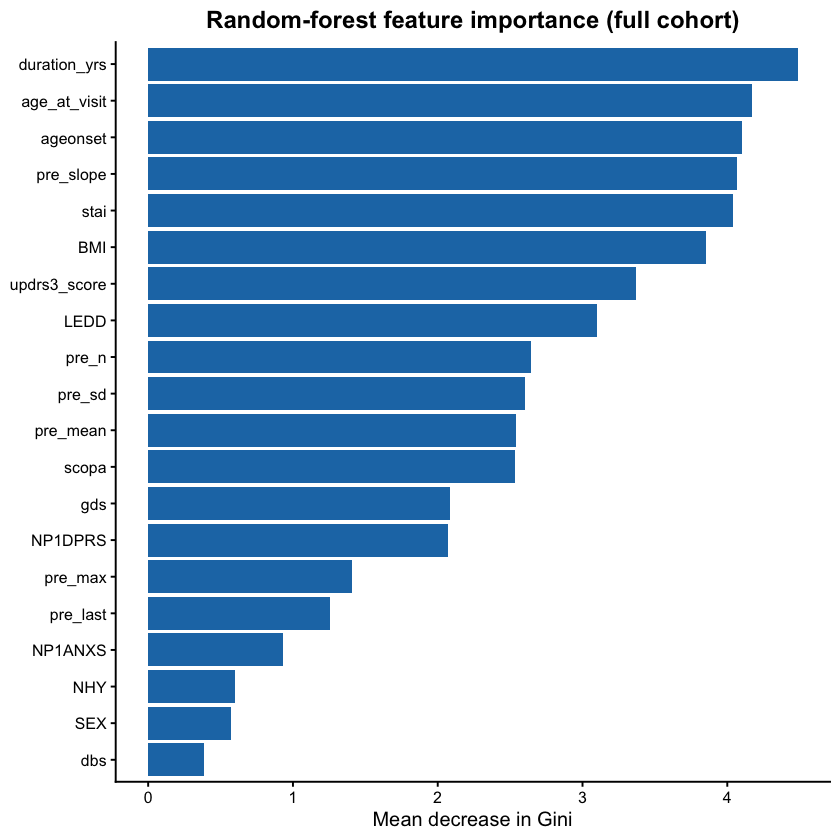

In [8]:
set.seed(42)
rf_full <- randomForest::randomForest(
  x = X, y = factor(y, levels = c(0, 1)),
  ntree = 1000, importance = TRUE
)
imp <- randomForest::importance(rf_full)
imp_df <- tibble::as_tibble(imp, rownames = "feature") %>%
  dplyr::arrange(dplyr::desc(MeanDecreaseGini))
print(imp_df, n = 30)
save_table(imp_df, "rf_importance_full_cohort")

p_imp <- ggplot(imp_df %>% dplyr::mutate(feature = forcats::fct_reorder(feature, MeanDecreaseGini)),
                aes(x = MeanDecreaseGini, y = feature)) +
  geom_col(fill = "#1f78b4") +
  labs(title = "Random-forest feature importance (full cohort)",
       x = "Mean decrease in Gini", y = NULL) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))
p_imp
save_fig(p_imp, "Fig12b_rf_importance_full_cohort", width = 6.5, height = 6)